# Sprint 1 – Definição do Problema e Análise Exploratória de Dados
### Grupo 4 · Engenharia de Software · Introdução à IA e Análise de Dados
**Prof. Wesley Andrade**

---

### Estrutura do notebook (5 seções conforme enunciado)
| # | Seção |
|---|---|
| 1 | Apresentação do Projeto |
| 2 | Carregamento e Visão Geral |
| 3 | Análise Univariada |
| 4 | Análise Bivariada e Multivariada |
| 5 | Achados e Hipóteses |


## Seção 1 · Apresentação do Projeto

### Nome do Projeto
**Previsão de Popularidade de Músicas no Spotify**

### Integrantes do Grupo
- Grupo 4 — Engenharia de Software

### Fonte e Link do Dataset
- **Nome:** Spotify Tracks Dataset
- **Fonte:** Kaggle
- **Link:** https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
- **Licença:** Open Database License (ODbL)

---

### Descrição do Problema

**Pergunta de negócio:** *Quais características musicais e de contexto (gênero, duração, características de áudio) influenciam a popularidade de uma faixa no Spotify, e é possível prever o score de popularidade de uma música com base nessas variáveis?*

O Spotify atribui a cada faixa um índice de `popularity` (0–100), calculado com base no número de reproduções recentes. Identificar os fatores que levam uma música a ter alta popularidade tem valor estratégico direto para gravadoras, produtores e artistas independentes.

### Justificativa

O mercado de streaming musical movimenta bilhões de dólares anualmente. Com mais de 100 milhões de faixas disponíveis no Spotify, a descoberta algorítmica é decisiva para o sucesso de um artista. Compreender quais atributos de áudio e de contexto (gênero, duração, caráter explícito) se associam à popularidade permite:

- Orientar decisões criativas de produção musical com base em dados
- Apoiar distribuidoras na priorização de lançamentos
- Identificar gêneros com maior potencial de alcance

### Tipo de Tarefa
**Regressão** — o target `popularity` é uma variável contínua (0–100 pontos).

---

### Descrição das Variáveis Principais

| Variável | Tipo | Descrição |
|---|---|---|
| `popularity` | int (0–100) | **TARGET** — score de popularidade calculado pelo Spotify com base em reproduções recentes |
| `track_genre` | categorical | Gênero musical da faixa (114 categorias únicas) |
| `danceability` | float (0–1) | Adequação da faixa para dançar (ritmo, batida, regularidade) |
| `energy` | float (0–1) | Intensidade e atividade perceptual da faixa |
| `loudness` | float (dB) | Volume médio em decibéis (normalmente entre -60 e 0 dB) |
| `speechiness` | float (0–1) | Presença de palavras faladas (> 0.66 = provável spoken word/comédia) |
| `acousticness` | float (0–1) | Confiança de que a faixa é acústica |
| `instrumentalness` | float (0–1) | Probabilidade de ausência de vocais |
| `liveness` | float (0–1) | Presença de audiência ao vivo (> 0.8 = provável gravação ao vivo) |
| `valence` | float (0–1) | Positividade musical (alto = alegre/eufórico, baixo = triste/tenso) |
| `tempo` | float (BPM) | Andamento estimado em batidas por minuto |
| `duration_ms` | int (ms) | Duração da faixa em milissegundos |
| `explicit` | bool | Se a faixa contém conteúdo explícito |
| `key` | int (0–11) | Tom musical (0=Dó, 1=Dó#, ..., 11=Si) |
| `mode` | int (0–1) | Modalidade (0 = menor, 1 = maior) |
| `time_signature` | int | Fórmula de compasso estimada (3, 4 ou 5 tempos) |


## Seção 2 · Carregamento e Visão Geral

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# ── Carregamento ──────────────────────────────────────────────────────────────
df = pd.read_csv('spotify-tracks-dataset.csv')
print(f"Dimensões do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")


Dimensões do dataset: 114,000 linhas × 22 colunas


In [ ]:
# ── Primeiras linhas ──────────────────────────────────────────────────────────
df.head(5)


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# ── Tipos de dados ────────────────────────────────────────────────────────────
print("=== Tipos de dados por coluna ===")
print(df.dtypes)


=== Tipos de dados por coluna ===
Unnamed: 0.1          int64
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [4]:
# ── Valores ausentes ──────────────────────────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(4)
missing_df = pd.DataFrame({'ausentes': nulos, 'pct_%': nulos_pct})
missing_df = missing_df[missing_df['ausentes'] > 0]

print("=== Colunas com valores ausentes ===")
if len(missing_df) == 0:
    print("Nenhuma coluna com valores ausentes!")
else:
    print(missing_df)

print(f"\nTotal de nulos no dataset: {df.isnull().sum().sum()}")
print(f"Linhas com ao menos 1 nulo: {df.isnull().any(axis=1).sum()}")


=== Colunas com valores ausentes ===
            ausentes   pct_%
artists            1  0.0009
album_name         1  0.0009
track_name         1  0.0009

Total de nulos no dataset: 3
Linhas com ao menos 1 nulo: 1


In [5]:
# ── Estatísticas descritivas ──────────────────────────────────────────────────
print("=== Estatísticas Descritivas — Variáveis Numéricas ===")
df.describe().round(3)


=== Estatísticas Descritivas — Variáveis Numéricas ===


,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,56999.50,56999.50,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,32909.11,32909.11,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.00,0.00,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,28499.75,28499.75,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,56999.50,56999.50,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,85499.25,85499.25,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.084,0.598,0.049,0.273,0.683,140.071,4.000
max,113999.00,113999.00,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


In [6]:
# ── Identificação do target e das features ────────────────────────────────────
TARGET = 'popularity'
ID_COLS = ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
CAT_COLS = ['track_genre', 'explicit']
NUM_COLS = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
            'duration_ms', 'time_signature']

print(f"TARGET: {TARGET}")
print(f"\nColunas de identificação ({len(ID_COLS)}): {ID_COLS}")
print(f"\nFeatures categóricas ({len(CAT_COLS)}): {CAT_COLS}")
print(f"\nFeatures numéricas ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nTotal de gêneros únicos: {df['track_genre'].nunique()}")
print(f"Track IDs duplicados (mesma música em múltiplos gêneros): {df['track_id'].duplicated().sum():,}")


TARGET: popularity

Colunas de identificação (6): ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']

Features categóricas (2): ['track_genre', 'explicit']

Features numéricas (13): ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']

Total de gêneros únicos: 114
Track IDs duplicados (mesma música em múltiplos gêneros): 24,259


## Seção 3 · Análise Univariada

### 3.1 Distribuição do Target: `popularity`


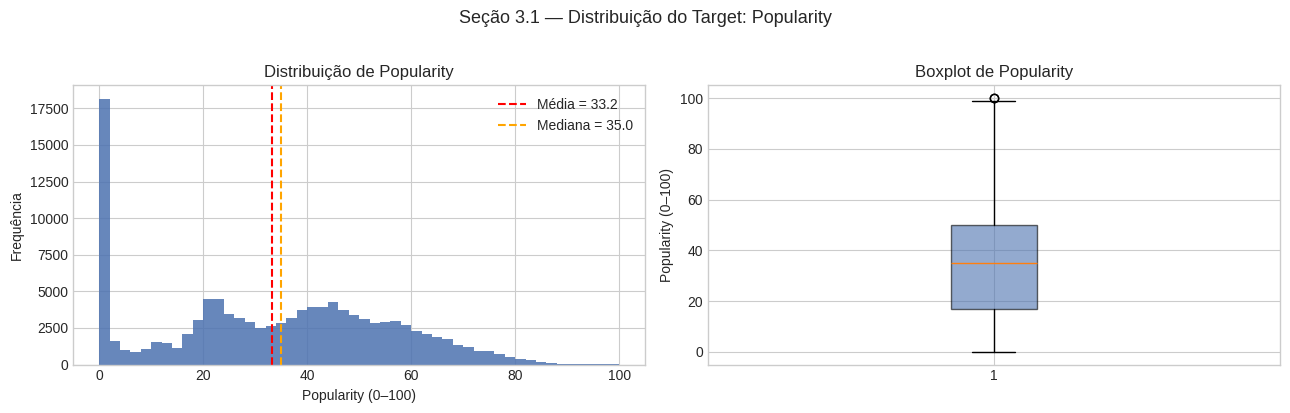

Média     : 33.24
Mediana   : 35.00
Desvio    : 22.31
Faixas com popularity = 0: 16,020 (14.1%)

Interpretação: a distribuição é levemente bimodal — há um pico em torno de 0
(músicas sem reproduções recentes) e outro em torno de 40–60 (músicas ativas).
A cauda direita é menos espessa: pouquíssimas músicas atingem popularity > 80.


In [7]:
# ── Distribuição do target ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['popularity'], bins=50, color='#4c72b0', alpha=0.85, edgecolor='none')
axes[0].axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Média = {df["popularity"].mean():.1f}')
axes[0].axvline(df['popularity'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mediana = {df["popularity"].median():.1f}')
axes[0].set_title('Distribuição de Popularity')
axes[0].set_xlabel('Popularity (0–100)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df['popularity'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4c72b0', alpha=0.6))
axes[1].set_title('Boxplot de Popularity')
axes[1].set_ylabel('Popularity (0–100)')

plt.suptitle('Seção 3.1 — Distribuição do Target: Popularity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Média     : {df['popularity'].mean():.2f}")
print(f"Mediana   : {df['popularity'].median():.2f}")
print(f"Desvio    : {df['popularity'].std():.2f}")
print(f"Faixas com popularity = 0: {(df['popularity']==0).sum():,} ({(df['popularity']==0).mean()*100:.1f}%)")
print("\nInterpretação: a distribuição é levemente bimodal — há um pico em torno de 0")
print("(músicas sem reproduções recentes) e outro em torno de 40–60 (músicas ativas).")
print("A cauda direita é menos espessa: pouquíssimas músicas atingem popularity > 80.")


### 3.2 Distribuição das Features Numéricas de Áudio

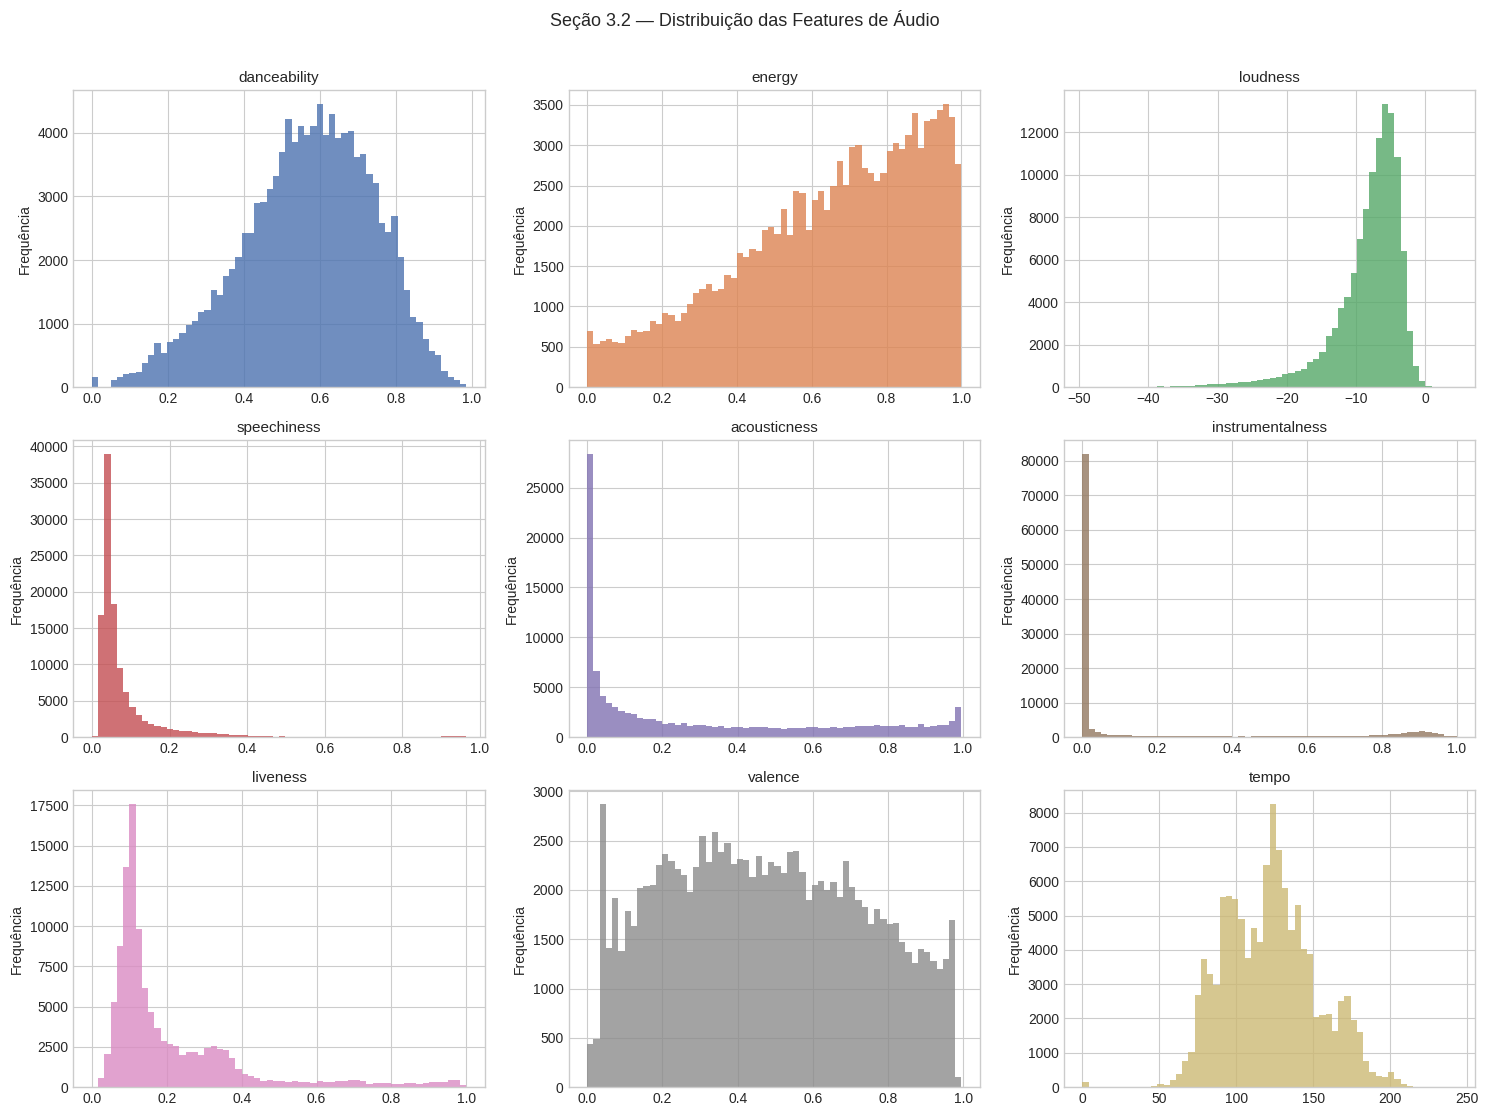

Interpretação:
• danceability e valence: distribuições aproximadamente normais, centradas em ~0.55
• energy: assimétrica à esquerda — maioria das faixas tem alta energia
• speechiness: fortemente assimétrica à direita — quase todas < 0.33 (músicas)
• instrumentalness: distribuição bimodal — muitas faixas com valor = 0 (com vocais)
  ou próximo de 1 (puramente instrumental), pouco valores intermediários
• loudness: distribuição aproximadamente normal entre -20 e -3 dB


In [8]:
# ── Histogramas das features de áudio ────────────────────────────────────────
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

colors = ['#4c72b0','#dd8452','#55a868','#c44e52','#8172b2',
          '#937860','#da8bc3','#8c8c8c','#ccb974']

for i, col in enumerate(audio_features):
    axes[i].hist(df[col], bins=60, color=colors[i], alpha=0.8, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Seção 3.2 — Distribuição das Features de Áudio', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Interpretação:")
print("• danceability e valence: distribuições aproximadamente normais, centradas em ~0.55")
print("• energy: assimétrica à esquerda — maioria das faixas tem alta energia")
print("• speechiness: fortemente assimétrica à direita — quase todas < 0.33 (músicas)")
print("• instrumentalness: distribuição bimodal — muitas faixas com valor = 0 (com vocais)")
print("  ou próximo de 1 (puramente instrumental), pouco valores intermediários")
print("• loudness: distribuição aproximadamente normal entre -20 e -3 dB")


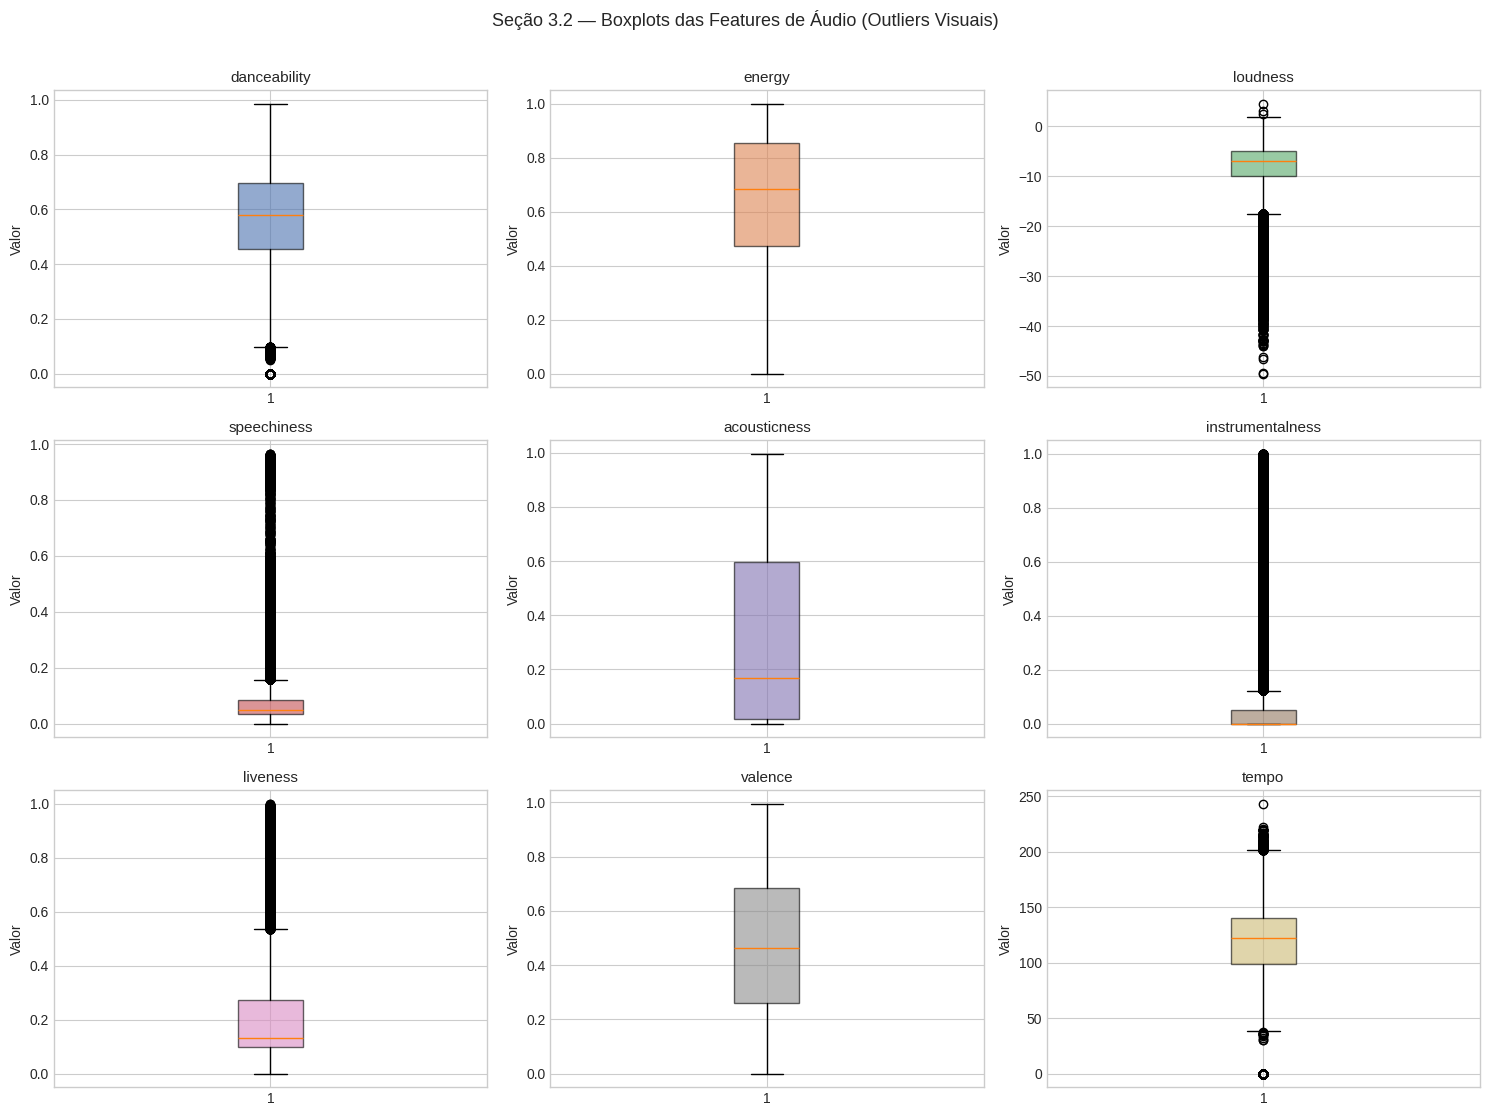

Outliers identificados visualmente:
• duration_ms: 1 faixa com duração = 0 ms (dado corrompido); 603 faixas > 10 min
• tempo: 157 faixas com BPM = 0 (fisicamente impossível — dado inválido)
• speechiness: cauda longa acima de 0.66 (880 faixas = provável spoken word/comédia)
• liveness: outliers acima de 0.8 (3,373 faixas — provável gravação ao vivo)
• loudness: outliers abaixo de -30 dB (730 faixas muito silenciosas)


In [9]:
# ── Boxplots para identificação de outliers ──────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(audio_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.6))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Valor')

plt.suptitle('Seção 3.2 — Boxplots das Features de Áudio (Outliers Visuais)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Outliers identificados visualmente:")
print(f"• duration_ms: 1 faixa com duração = 0 ms (dado corrompido); {(df['duration_ms']>600000).sum()} faixas > 10 min")
print(f"• tempo: {(df['tempo']==0).sum()} faixas com BPM = 0 (fisicamente impossível — dado inválido)")
print(f"• speechiness: cauda longa acima de 0.66 ({(df['speechiness']>0.66).sum()} faixas = provável spoken word/comédia)")
print(f"• liveness: outliers acima de 0.8 ({(df['liveness']>0.8).sum():,} faixas — provável gravação ao vivo)")
print(f"• loudness: outliers abaixo de -30 dB ({(df['loudness']<-30).sum():,} faixas muito silenciosas)")


### 3.3 Variáveis Categóricas

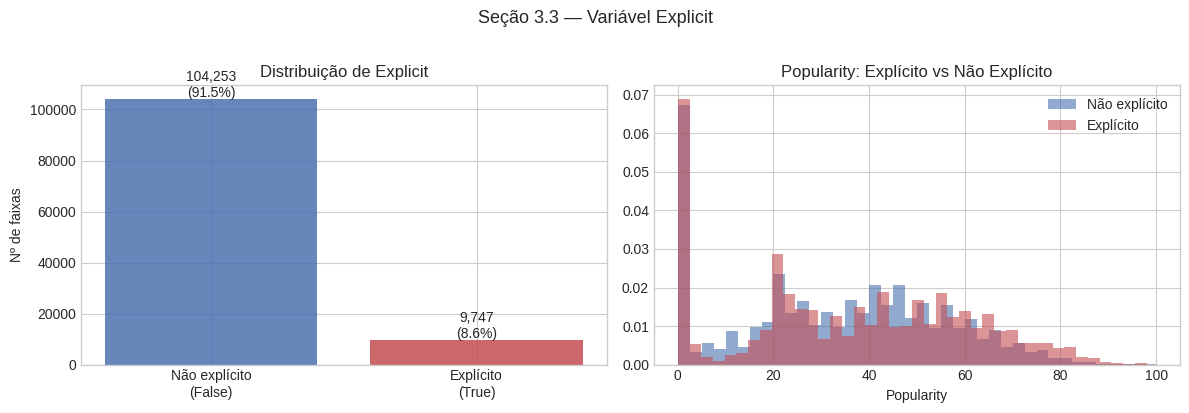

Faixas NÃO explícitas — média: 32.94  mediana: 34.0
Faixas EXPLÍCITAS     — média: 36.45  mediana: 37.0

Interpretação: faixas com conteúdo explícito têm popularidade levemente superior,
possivelmente associadas a gêneros como hip-hop e funk que tendem a ter maior alcance recente.


In [10]:
# ── Explicit ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem
explicit_counts = df['explicit'].value_counts()
axes[0].bar(['Não explícito\n(False)', 'Explícito\n(True)'],
            explicit_counts.values,
            color=['#4c72b0', '#c44e52'], alpha=0.85)
axes[0].set_title('Distribuição de Explicit')
axes[0].set_ylabel('Nº de faixas')
for i, v in enumerate(explicit_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Distribuição de popularity por explicit
df_exp_0 = df[df['explicit']==False]['popularity']
df_exp_1 = df[df['explicit']==True]['popularity']
axes[1].hist(df_exp_0, bins=40, alpha=0.6, color='#4c72b0', label='Não explícito', density=True)
axes[1].hist(df_exp_1, bins=40, alpha=0.6, color='#c44e52', label='Explícito', density=True)
axes[1].set_title('Popularity: Explícito vs Não Explícito')
axes[1].set_xlabel('Popularity')
axes[1].legend()

plt.suptitle('Seção 3.3 — Variável Explicit', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

exp_pop = df.groupby('explicit')['popularity'].agg(['mean','median'])
print(f"Faixas NÃO explícitas — média: {exp_pop.loc[False,'mean']:.2f}  mediana: {exp_pop.loc[False,'median']:.1f}")
print(f"Faixas EXPLÍCITAS     — média: {exp_pop.loc[True,'mean']:.2f}  mediana: {exp_pop.loc[True,'median']:.1f}")
print("\nInterpretação: faixas com conteúdo explícito têm popularidade levemente superior,")
print("possivelmente associadas a gêneros como hip-hop e funk que tendem a ter maior alcance recente.")


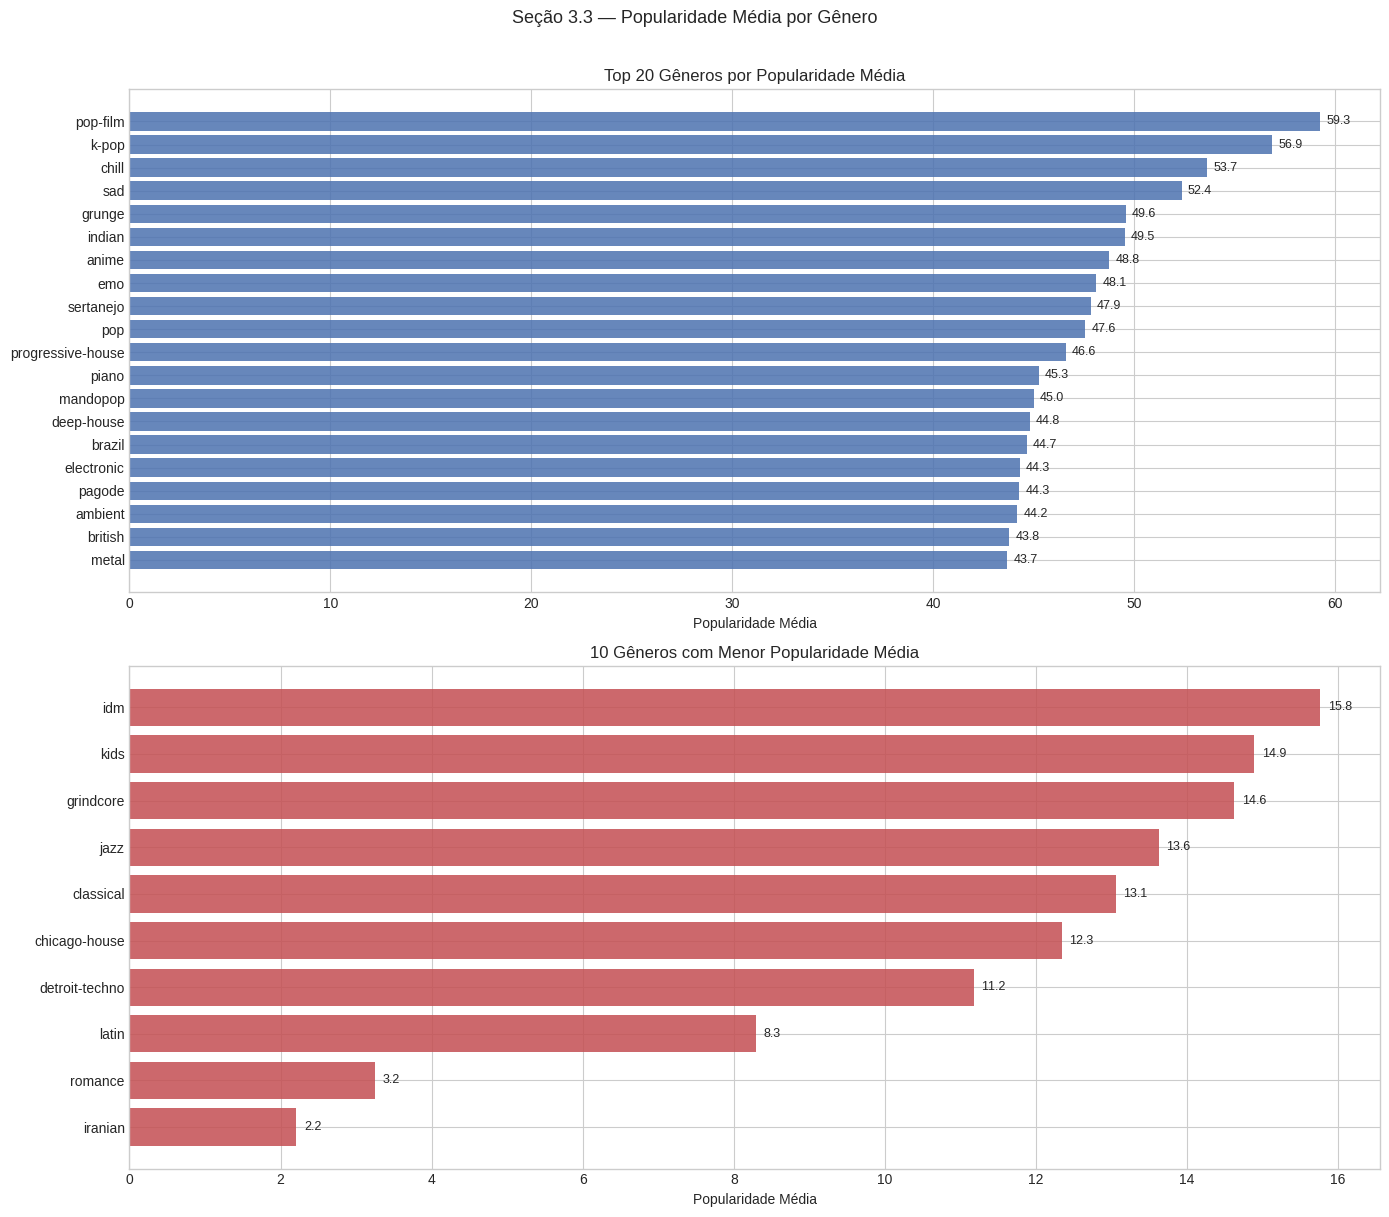

Interpretação:
• pop-film (59.3) e k-pop (56.9) lideram — gêneros com forte presença em plataformas de streaming
• iranian (2.2) e romance (3.2) têm popularidade muito baixa — nichos muito específicos
• A variação entre gêneros (2.2 a 59.3) é enorme, sugerindo que o GÊNERO é uma feature
  muito informativa para prever popularidade


In [11]:
# ── Distribuição por gênero (top 20 e bottom 10 por popularidade média) ───────
pop_por_genero = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
top20 = pop_por_genero.head(20)
bot10 = pop_por_genero.tail(10)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 20
axes[0].barh(top20.index[::-1], top20.values[::-1], color='#4c72b0', alpha=0.85)
axes[0].set_title('Top 20 Gêneros por Popularidade Média', fontsize=12)
axes[0].set_xlabel('Popularidade Média')
for i, v in enumerate(top20.values[::-1]):
    axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

# Bottom 10
axes[1].barh(bot10.index[::-1], bot10.values[::-1], color='#c44e52', alpha=0.85)
axes[1].set_title('10 Gêneros com Menor Popularidade Média', fontsize=12)
axes[1].set_xlabel('Popularidade Média')
for i, v in enumerate(bot10.values[::-1]):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Seção 3.3 — Popularidade Média por Gênero', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Interpretação:")
print("• pop-film (59.3) e k-pop (56.9) lideram — gêneros com forte presença em plataformas de streaming")
print("• iranian (2.2) e romance (3.2) têm popularidade muito baixa — nichos muito específicos")
print("• A variação entre gêneros (2.2 a 59.3) é enorme, sugerindo que o GÊNERO é uma feature")
print("  muito informativa para prever popularidade")


## Seção 4 · Análise Bivariada e Multivariada

### 4.1 Correlação entre Features Numéricas (Heatmap)


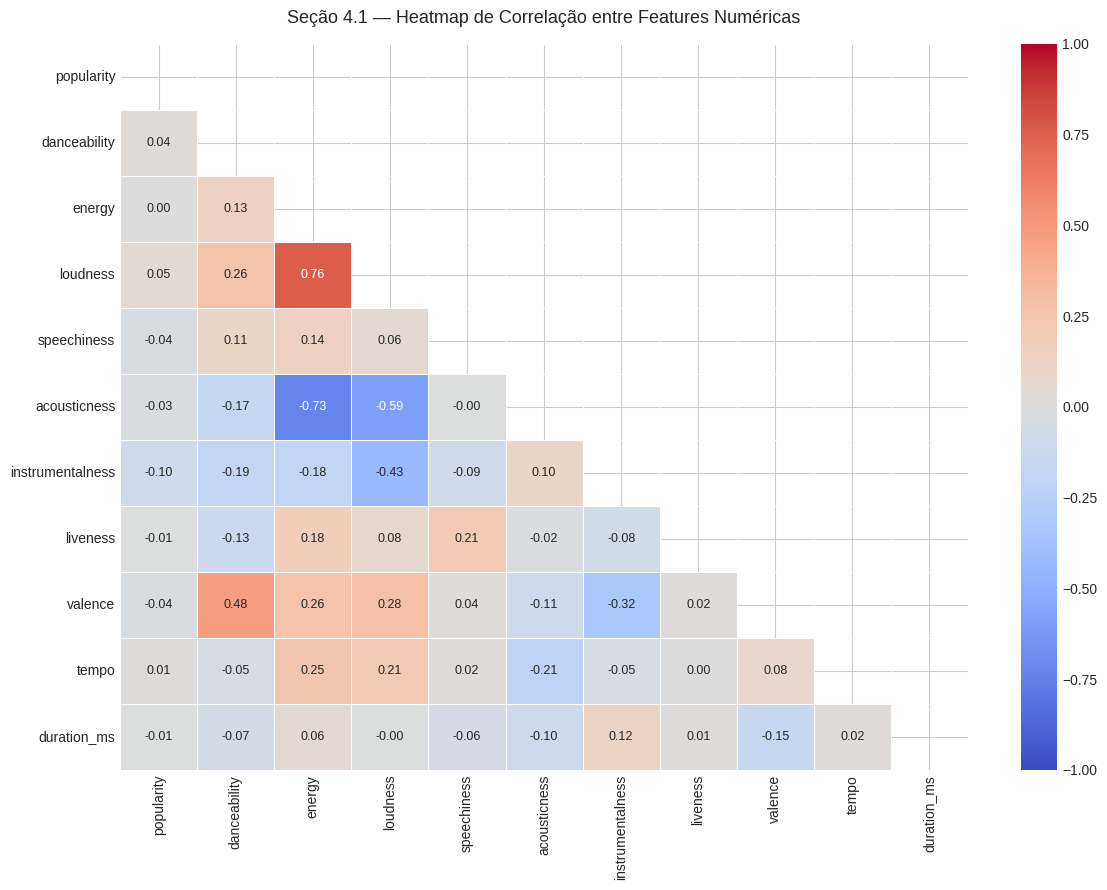

Principais correlações identificadas:
• energy × loudness: +0.76 (faixas energéticas tendem a ser mais altas — esperado)
• energy × acousticness: -0.73 (faixas acústicas têm menor energia — esperado)
• energy × valence: +0.40 (músicas energéticas tendem a ser mais positivas)
• danceability × valence: +0.41 (músicas dançantes tendem a ser mais alegres)
• instrumentalness × energy: -0.34 (faixas instrumentais tendem a ter menos energia)

Com o TARGET (popularity), as correlações são fracas (< |0.10|),
indicando que nenhuma feature de áudio sozinha é fortemente preditiva.
Isso sugere que relações NÃO-LINEARES ou COMBINAÇÕES de features serão mais relevantes.


In [12]:
# ── Heatmap de correlação ─────────────────────────────────────────────────────
num_features = ['popularity','danceability','energy','loudness','speechiness',
                'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']

corr_matrix = df[num_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 9}, linewidths=0.5)
ax.set_title('Seção 4.1 — Heatmap de Correlação entre Features Numéricas', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("Principais correlações identificadas:")
print("• energy × loudness: +0.76 (faixas energéticas tendem a ser mais altas — esperado)")
print("• energy × acousticness: -0.73 (faixas acústicas têm menor energia — esperado)")
print("• energy × valence: +0.40 (músicas energéticas tendem a ser mais positivas)")
print("• danceability × valence: +0.41 (músicas dançantes tendem a ser mais alegres)")
print("• instrumentalness × energy: -0.34 (faixas instrumentais tendem a ter menos energia)")
print("\nCom o TARGET (popularity), as correlações são fracas (< |0.10|),")
print("indicando que nenhuma feature de áudio sozinha é fortemente preditiva.")
print("Isso sugere que relações NÃO-LINEARES ou COMBINAÇÕES de features serão mais relevantes.")


### 4.2 Relação de cada Feature com o Target (Popularity)

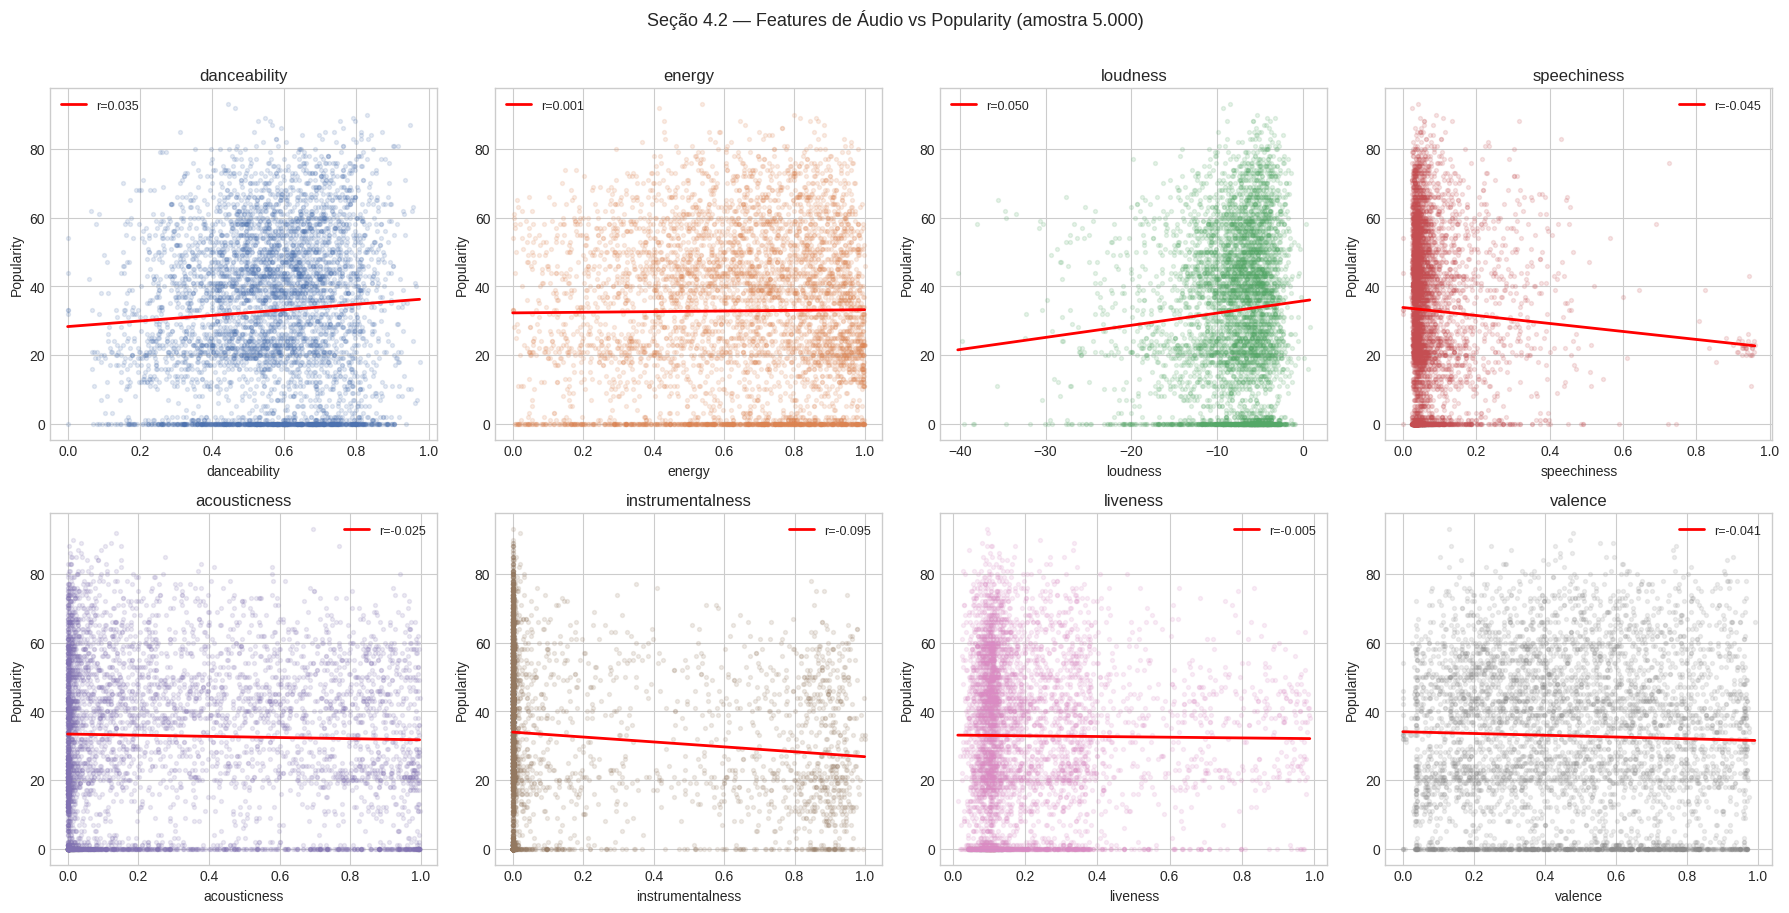

Interpretação:
• Nenhuma feature isolada apresenta relação linear clara com popularity
• speechiness: distribuição em dois grupos — músicas (< 0.33) vs spoken word (> 0.66)
• instrumentalness: músicas com valores próximos de 1 têm popularidade consistentemente baixa
• loudness: correlação positiva fraca — faixas mais altas tendem a ser levemente mais populares


In [13]:
# ── Scatter plots: features vs popularity ─────────────────────────────────────
features_scatter = ['danceability', 'energy', 'loudness', 'speechiness',
                    'acousticness', 'instrumentalness', 'liveness', 'valence']

# Amostra para visualização (dataset completo é pesado para scatter)
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(features_scatter):
    axes[i].scatter(sample[col], sample['popularity'], alpha=0.15, s=8, color=colors[i])
    # Linha de tendência
    z = np.polyfit(sample[col].dropna(), sample.loc[sample[col].notna(), 'popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[col].min(), sample[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, label=f'r={df[col].corr(df["popularity"]):.3f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Popularity')
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

plt.suptitle('Seção 4.2 — Features de Áudio vs Popularity (amostra 5.000)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Interpretação:")
print("• Nenhuma feature isolada apresenta relação linear clara com popularity")
print("• speechiness: distribuição em dois grupos — músicas (< 0.33) vs spoken word (> 0.66)")
print("• instrumentalness: músicas com valores próximos de 1 têm popularidade consistentemente baixa")
print("• loudness: correlação positiva fraca — faixas mais altas tendem a ser levemente mais populares")


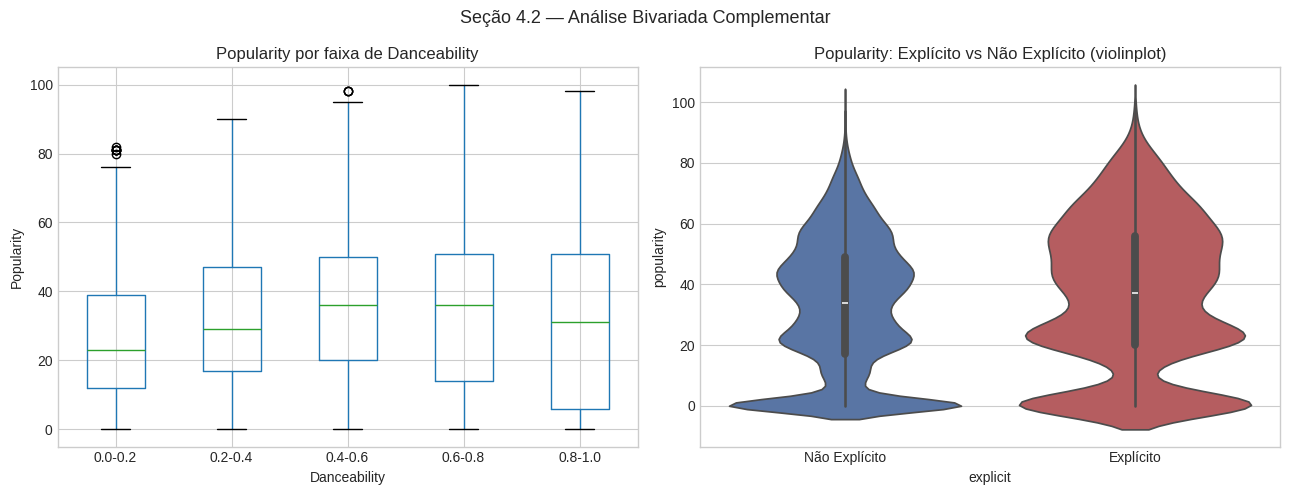

Interpretação:
• Danceability alta (0.6–0.8) está associada a popularidade ligeiramente maior
• Danceability muito alta (0.8–1.0) não garante mais popularidade — relação não-linear
• O violinplot confirma que faixas explícitas têm distribuição de popularity com cauda
  superior levemente mais espessa, mas a diferença é pequena


In [14]:
# ── Popularity por faixa de danceability (binning) ────────────────────────────
df['dance_bin'] = pd.cut(df['danceability'],
                          bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                          labels=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot por faixa de danceability
df.boxplot(column='popularity', by='dance_bin', ax=axes[0])
axes[0].set_title('Popularity por faixa de Danceability')
axes[0].set_xlabel('Danceability')
axes[0].set_ylabel('Popularity')
plt.sca(axes[0])
plt.title('Popularity por faixa de Danceability')

# Violinplot: explicit vs popularity
sns.violinplot(data=df, x='explicit', y='popularity', ax=axes[1],
               palette=['#4c72b0', '#c44e52'])
axes[1].set_title('Popularity: Explícito vs Não Explícito (violinplot)')
axes[1].set_xticklabels(['Não Explícito', 'Explícito'])

plt.suptitle('Seção 4.2 — Análise Bivariada Complementar', fontsize=13)
plt.tight_layout()
plt.show()

print("Interpretação:")
print("• Danceability alta (0.6–0.8) está associada a popularidade ligeiramente maior")
print("• Danceability muito alta (0.8–1.0) não garante mais popularidade — relação não-linear")
print("• O violinplot confirma que faixas explícitas têm distribuição de popularity com cauda")
print("  superior levemente mais espessa, mas a diferença é pequena")


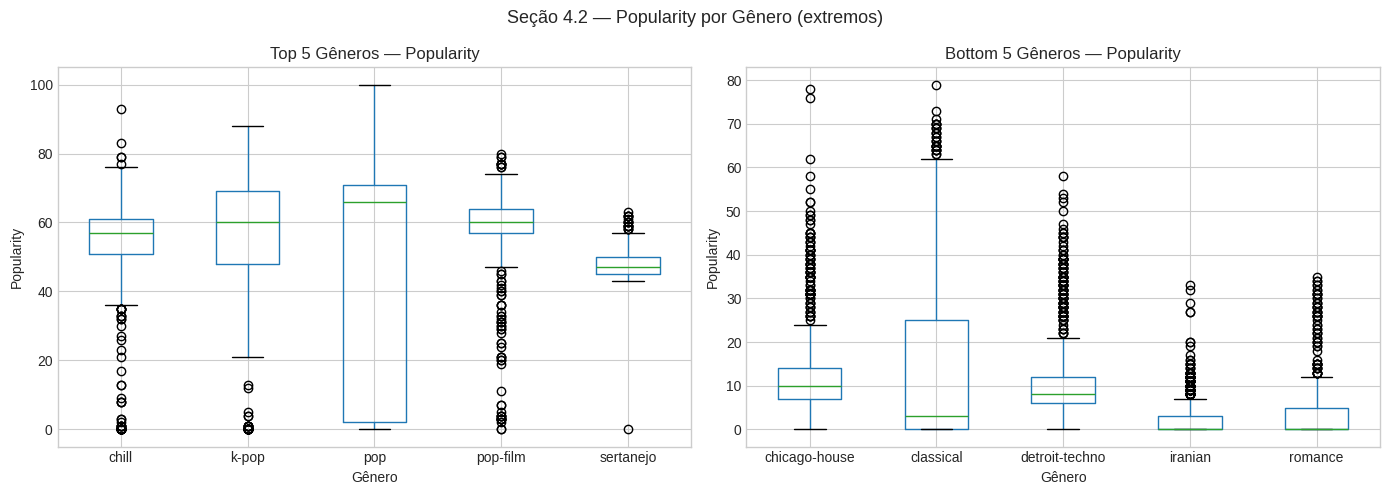

Interpretação:
• A variância de popularity DENTRO de cada gênero ainda é alta:
  mesmo pop-film tem faixas com popularity próxima de 0
• O gênero é informativo, mas não determinístico — outros fatores também importam


In [15]:
# ── Top 5 gêneros em detalhe: boxplot de popularity ───────────────────────────
top5_gen = ['pop-film', 'k-pop', 'chill', 'pop', 'sertanejo']
bot5_gen = ['iranian', 'romance', 'detroit-techno', 'chicago-house', 'classical']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['track_genre'].isin(top5_gen)].boxplot(
    column='popularity', by='track_genre', ax=axes[0])
axes[0].set_title('Top 5 Gêneros — Distribuição de Popularity')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Popularity')
plt.sca(axes[0]); plt.title('Top 5 Gêneros — Popularity')

df[df['track_genre'].isin(bot5_gen)].boxplot(
    column='popularity', by='track_genre', ax=axes[1])
axes[1].set_title('5 Gêneros Menos Populares — Distribuição de Popularity')
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Popularity')
plt.sca(axes[1]); plt.title('Bottom 5 Gêneros — Popularity')

plt.suptitle('Seção 4.2 — Popularity por Gênero (extremos)', fontsize=13)
plt.tight_layout()
plt.show()

print("Interpretação:")
print("• A variância de popularity DENTRO de cada gênero ainda é alta:")
print("  mesmo pop-film tem faixas com popularity próxima de 0")
print("• O gênero é informativo, mas não determinístico — outros fatores também importam")


### 4.3 Identificação de Features Potencialmente Preditivas e Redundantes

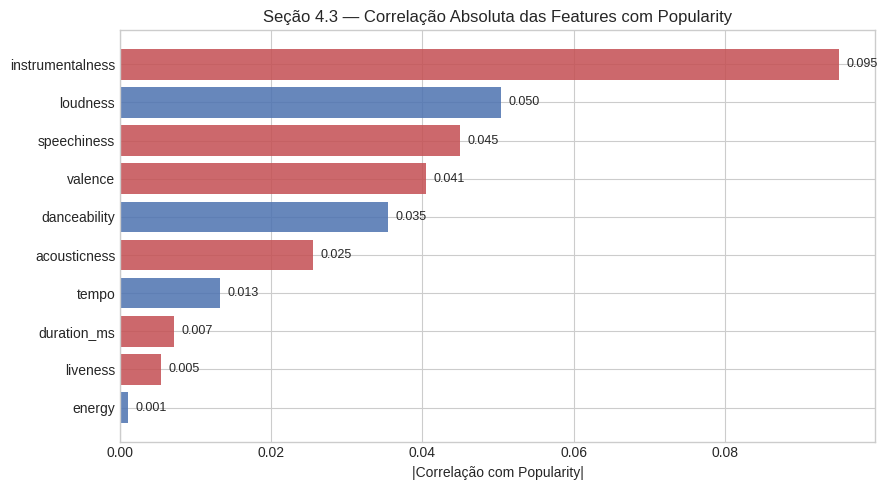

Features potencialmente preditivas (correlação > 0.03):
instrumentalness    0.095139
loudness            0.050423
speechiness         0.044927
valence             0.040534
danceability        0.035448

Features potencialmente redundantes (altamente correlacionadas entre si):
• energy × loudness (r=0.76): podem ser redundantes entre si
• energy × acousticness (r=-0.73): relação inversa forte — uma pode ser suficiente
• danceability × valence (r=0.41): alguma sobreposição de informação

IMPORTANTE: correlação linear fraca com o target NÃO significa que a feature é inútil.
Modelos não-lineares (árvores, boosting) podem extrair valor dessas features mesmo
sem correlação linear significativa.


In [16]:
# ── Features potencialmente preditivas ────────────────────────────────────────
corr_target = df[num_features].corr()['popularity'].drop('popularity').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#4c72b0' if v > 0 else '#c44e52'
              for v in df[num_features].corr()['popularity'].drop('popularity').loc[corr_target.index].values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel('|Correlação com Popularity|')
ax.set_title('Seção 4.3 — Correlação Absoluta das Features com Popularity')
for i, v in enumerate(corr_target.values[::-1]):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Features potencialmente preditivas (correlação > 0.03):")
print(corr_target[corr_target > 0.03].to_string())
print("\nFeatures potencialmente redundantes (altamente correlacionadas entre si):")
print("• energy × loudness (r=0.76): podem ser redundantes entre si")
print("• energy × acousticness (r=-0.73): relação inversa forte — uma pode ser suficiente")
print("• danceability × valence (r=0.41): alguma sobreposição de informação")
print("\nIMPORTANTE: correlação linear fraca com o target NÃO significa que a feature é inútil.")
print("Modelos não-lineares (árvores, boosting) podem extrair valor dessas features mesmo")
print("sem correlação linear significativa.")


## Seção 5 · Achados e Hipóteses

### 5.1 Resumo dos Principais Achados da EDA

**Sobre o dataset:**
- 114.000 faixas, 22 colunas, 114 gêneros musicais com exatamente 1.000 faixas cada
- Apenas 3 valores ausentes (< 0.003%), todos na mesma linha, em colunas de identificação de texto
- 24.259 `track_id` duplicados: a mesma música aparece em múltiplos gêneros (dataset organizado por gênero, não por faixa)

**Sobre o target (`popularity`):**
- Média de 33.2 e mediana de 35 — distribuição assimétrica com 16.020 faixas com popularity = 0 (faixas sem reproduções recentes)
- Cauda direita curta: apenas ~5% das faixas ultrapassam popularity 70

**Sobre as features de áudio:**
- Correlações lineares com popularity são fracas (todas < |0.10|) — relações não-lineares e interações entre features serão mais relevantes
- `instrumentalness` tem a maior correlação negativa com popularity (-0.095): faixas instrumentais tendem a ser menos populares
- `energy` e `loudness` são altamente correlacionadas entre si (r=0.76) — possível redundância
- `speechiness` > 0.66 identifica 880 faixas de spoken word/comédia, incluindo 767 faixas do gênero `comedy` — conteúdo não-musical que pode distorcer o modelo

**Sobre os gêneros:**
- Variação enorme de popularidade entre gêneros: de 2.2 (iranian) a 59.3 (pop-film)
- O gênero musical é provavelmente a feature mais informativa do dataset

**Problemas de qualidade identificados:**
- 1 faixa com `duration_ms = 0` (dado corrompido)
- 157 faixas com `tempo = 0` BPM (fisicamente impossível)
- 603 faixas com duração > 10 minutos (possíveis outliers extremos)
- Gênero `comedy`: 1.000 faixas de stand-up/comédia falada — conteúdo não-musical

---

### 5.2 Hipóteses Formuladas

**Hipótese 1:** *Acreditamos que o gênero musical está muito mais fortemente associado à popularidade do que as métricas de áudio individuais, porque a variância de popularidade entre gêneros (de 2.2 a 59.3 pontos) é muito maior do que qualquer correlação observada entre as features de áudio e o target (todas < |0.10|).*

**Hipótese 2:** *Acreditamos que faixas instrumentais (`instrumentalness` > 0.5) são sistematicamente menos populares porque músicas sem vocais têm menor apelo de massa e tendem a pertencer a gêneros de nicho (classical, ambient, jazz instrumental), que apresentam as menores popularidades médias do dataset.*

**Hipótese 3:** *Acreditamos que a combinação de alta dançabilidade (`danceability` > 0.7) com alta energia (`energy` > 0.7) prediz melhor a popularidade do que cada uma dessas features isoladamente, porque os gêneros mais populares (pop-film, k-pop, pop, sertanejo) são caracterizados precisamente por essa combinação de atributos — enquanto há músicas energéticas mas não dançantes (rock pesado) e músicas dançantes mas não energéticas (lofi) com popularidades variadas.*

---

### 5.3 Desafios para o Pré-processamento (Sprint 2)

| Coluna | Problema | Ação planejada |
|---|---|---|
| `artists`, `album_name`, `track_name` | 3 nulos (0.003%) | Remoção das linhas afetadas |
| `Unnamed: 0.1`, `Unnamed: 0`, `track_id`, `artists`, `album_name`, `track_name` | Colunas de identificação — sem valor preditivo | Remoção das colunas |
| `duration_ms` | 1 faixa com valor 0; 603 > 10 min | Remover zero; avaliar cap no percentil 99 |
| `tempo` | 157 faixas com valor 0 BPM | Imputação pela mediana do gênero |
| `instrumentalness` | Distribuição hiper-assimétrica (bimodal) | Transformação logarítmica (log1p) |
| `speechiness`, `acousticness`, `liveness`, `loudness` | Caudas longas / outliers | Winsorização (percentil 1–99) |
| `track_genre` | Variável categórica nominal com 114 categorias | Target Encoding (média de popularity por gênero) |
| `explicit` | Variável booleana | Conversão para int (0/1) |
| `key` | Variável circular (notas musicais 0–11) | Encoding seno/cosseno para preservar a topologia circular |
| `comedy` (gênero) | Conteúdo não-musical (spoken word/stand-up) | Avaliar remoção do gênero ou flag especial |


In [17]:
# ── Resumo quantitativo dos desafios ──────────────────────────────────────────
print("=== RESUMO QUANTITATIVO DOS DESAFIOS DE PRÉ-PROCESSAMENTO ===\n")

print(f"1. Valores ausentes: {df.isnull().sum().sum()} nulos em 3 colunas ({df.isnull().any(axis=1).sum()} linhas)")
print(f"2. duration_ms = 0: {(df['duration_ms']==0).sum()} linha(s)")
print(f"3. duration_ms > 10 min: {(df['duration_ms']>600000).sum()} faixas")
print(f"4. tempo = 0 BPM: {(df['tempo']==0).sum()} faixas")
print(f"5. track_id duplicados: {df['track_id'].duplicated().sum():,} (mesma música em múltiplos gêneros)")
print(f"6. Spoken word (speechiness > 0.66): {(df['speechiness']>0.66).sum()} faixas")
print(f"7. Gênero 'comedy' (não-musical): {(df['track_genre']=='comedy').sum()} faixas")
print(f"8. track_genre: {df['track_genre'].nunique()} categorias únicas → precisa de encoding")
print(f"9. Faixas com popularity = 0: {(df['popularity']==0).sum():,} ({(df['popularity']==0).mean()*100:.1f}%)")
print(f"\nShape original: {df.shape}")
print("Shape após remover colunas de identificação (estimado): 114.000 × 16")


=== RESUMO QUANTITATIVO DOS DESAFIOS DE PRÉ-PROCESSAMENTO ===

1. Valores ausentes: 160 nulos em 3 colunas (158 linhas)
2. duration_ms = 0: 1 linha(s)
3. duration_ms > 10 min: 603 faixas
4. tempo = 0 BPM: 157 faixas
5. track_id duplicados: 24,259 (mesma música em múltiplos gêneros)
6. Spoken word (speechiness > 0.66): 880 faixas
7. Gênero 'comedy' (não-musical): 1000 faixas
8. track_genre: 114 categorias únicas → precisa de encoding
9. Faixas com popularity = 0: 16,020 (14.1%)

Shape original: (114000, 23)
Shape após remover colunas de identificação (estimado): 114.000 × 16
